In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.multiprocessing
torch.multiprocessing.set_start_method("spawn", force=True)

In [4]:
import ray
from ray import tune, train
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import ASHAScheduler
from ray import air

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-14 15:42:15,948	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-14 15:42:16,199	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [5]:
# Load the TSV dataset
df = pd.read_csv('English-Hindi.tsv', sep='\t', header=None, names=["id1", "en", "id2", "hi"])

In [6]:
# Show a sample
df.sample(5)

,id1,en,id2,hi
4674,1063994,Don't ask her any questions about her marriage.,2072510,उसकी शादी के बारे में उससे कोई सवाल मत पूछें।
3181,308138,I don't know if she will go there with me.,483942,मुझे नहीं पता वह मेरे साथ वहाँ जाएगी कि नहीं।
10697,462476,Stay there.,6830409,वहीं रहिए।
6428,2915481,Where is your friend?,3299682,तुम्हारा दोस्त कहाँ है?
339,23855,Twenty people perished in the blaze.,485537,आग में बीस लोग चल बसे।


In [7]:
# Keep only the English and Hindi columns
df = df[["en", "hi"]]

In [8]:
#df = df.sample(20000)

In [9]:
# Drop any rows with missing data
df.dropna(inplace=True)

In [10]:
# Reset index
df.reset_index(drop=True, inplace=True)

In [11]:
# Preview cleaned data
df.head()

,en,hi
0,Muiriel is 20 now.,म्यूरियल अब बीस साल की हो गई है।
1,Muiriel is 20 now.,म्यूरियल अब बीस साल की है।
2,Education in this world disappoints me.,मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।
3,That won't happen.,वैसा नहीं होगा।
4,I miss you.,मुझें तुम्हारी याद आ रही है।


In [12]:
# Number of sentence pairs
print("Total pairs:", len(df))

Total pairs: 13186


In [13]:
# Sentence length distributions
df["en_len"] = df["en"].apply(lambda x: len(x.split()))
df["hi_len"] = df["hi"].apply(lambda x: len(x.split()))

In [14]:
print("\nEnglish Sentence Length Stats:")
print(df["en_len"].describe())


English Sentence Length Stats:
count    13186.000000
mean         5.607614
std          2.676713
min          1.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         53.000000
Name: en_len, dtype: float64


In [15]:
print("\nHindi Sentence Length Stats:")
print(df["hi_len"].describe())


Hindi Sentence Length Stats:
count    13186.000000
mean         6.277719
std          2.999823
min          1.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         57.000000
Name: hi_len, dtype: float64


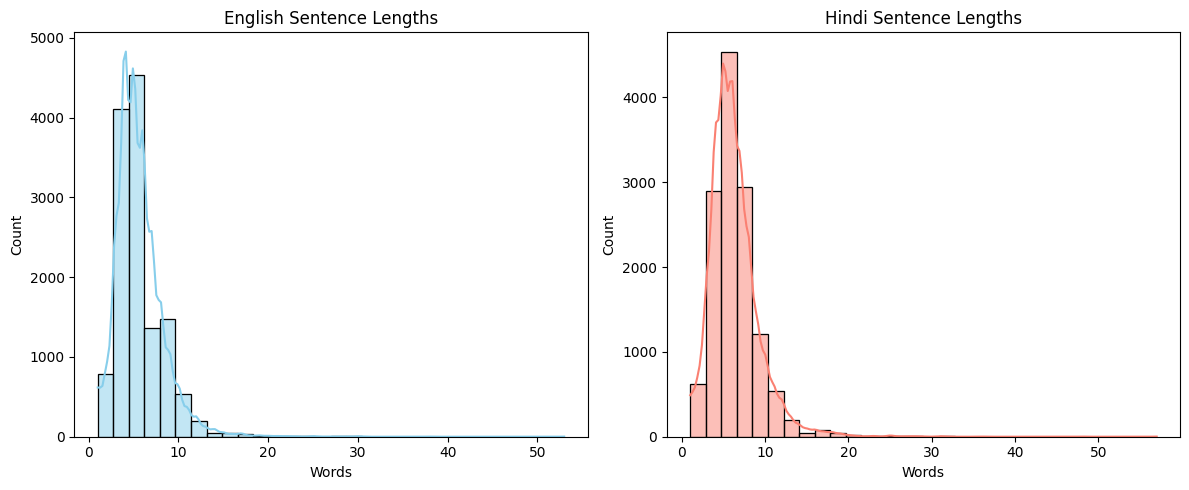

In [16]:
plt.figure(figsize=(12, 5))

# English
plt.subplot(1, 2, 1)
sns.histplot(df["en_len"], bins=30, kde=True, color='skyblue')
plt.title("English Sentence Lengths")
plt.xlabel("Words")

# Hindi
plt.subplot(1, 2, 2)
sns.histplot(df["hi_len"], bins=30, kde=True, color='salmon')
plt.title("Hindi Sentence Lengths")
plt.xlabel("Words")

plt.tight_layout()
plt.show()

In [17]:
for i in range(5):
    print(f"EN: {df.loc[i, 'en']}")
    print(f"HI: {df.loc[i, 'hi']}")
    print("---")

EN: Muiriel is 20 now.
HI: म्यूरियल अब बीस साल की हो गई है।
---
EN: Muiriel is 20 now.
HI: म्यूरियल अब बीस साल की है।
---
EN: Education in this world disappoints me.
HI: मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।
---
EN: That won't happen.
HI: वैसा नहीं होगा।
---
EN: I miss you.
HI: मुझें तुम्हारी याद आ रही है।
---


In [18]:
def tokenize(sentence):
    return sentence.lower().strip().split()

In [19]:
from collections import Counter
import itertools

In [20]:
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.freq_threshold = freq_threshold
        self.itos = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.idx = 4

    def build_vocab(self, sentence_list):
        frequencies = Counter()
        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1

        for word, freq in frequencies.items():
            if freq >= self.freq_threshold:
                self.stoi[word] = self.idx
                self.itos[self.idx] = word
                self.idx += 1

    def tokenize(self, sentence):
        return sentence.lower().strip().split()

    def numericalize(self, sentence):
        tokens = self.tokenize(sentence)
        return [self.stoi.get(token, self.stoi["<unk>"]) for token in tokens]

    def __len__(self):
        return len(self.stoi)

    def __getitem__(self, token):
        return self.stoi.get(token, self.stoi["<unk>"])

In [21]:
# Create vocab instances
en_vocab = Vocabulary(freq_threshold=2)
hi_vocab = Vocabulary(freq_threshold=2)

In [22]:
# Build vocabs
en_vocab.build_vocab(df["en"].tolist())
hi_vocab.build_vocab(df["hi"].tolist())

In [23]:
print(f"English vocab size: {len(en_vocab.stoi)}")
print(f"Hindi vocab size: {len(hi_vocab.stoi)}")

English vocab size: 4117
Hindi vocab size: 4044


In [24]:
def encode_sentence(sentence, vocab, max_len=50):
    tokens = [vocab.stoi["<sos>"]] + vocab.numericalize(sentence)[:max_len-2] + [vocab.stoi["<eos>"]]
    return tokens + [vocab.stoi["<pad>"]] * (max_len - len(tokens))

In [25]:
sample_en = "That won't happen."
sample_hi = "वैसा नहीं होगा।"

In [26]:
print("Encoded English:", encode_sentence(sample_en, en_vocab))
print("Encoded Hindi:", encode_sentence(sample_hi, hi_vocab))

Encoded English: [1, 13, 14, 15, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Encoded Hindi: [1, 21, 22, 23, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [27]:
import torch
import torch.nn as nn
import math

In [28]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [29]:
def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    attention = torch.softmax(scores, dim=-1)
    return torch.matmul(attention, v), attention

In [30]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.query_linear = nn.Linear(d_model, d_model)
        self.key_linear = nn.Linear(d_model, d_model)
        self.value_linear = nn.Linear(d_model, d_model)

        self.out_linear = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        # Project Q, K, V
        Q = self.query_linear(q)  # [B, T, D]
        K = self.key_linear(k)
        V = self.value_linear(v)

        # Reshape and transpose: [B, T, D] -> [B, H, T, Dk]
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)  # [B, H, T, Dk]
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Apply scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)
        attention_output = torch.matmul(self.dropout(attention_weights), V)  # [B, H, T, Dk]

        # Concatenate heads: [B, H, T, Dk] -> [B, T, H * Dk]
        attention_output = attention_output.transpose(1, 2).contiguous() \
                                            .view(batch_size, -1, self.d_model)

        return self.out_linear(attention_output)

In [31]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=2048, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))

In [32]:
class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta

In [33]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, mask)))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x

In [34]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)

        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.norm3 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, tgt_mask)))
        x = self.norm2(x + self.dropout(self.cross_attn(x, enc_out, enc_out, src_mask)))
        x = self.norm3(x + self.dropout(self.ffn(x)))
        return x

In [35]:
class Encoder(nn.Module):
    def __init__(self, input_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(input_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.embed(x)
        x = self.pos_enc(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, mask)

        return x

In [36]:
class Decoder(nn.Module):
    def __init__(self, target_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(target_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.embed(x)
        x = self.pos_enc(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, enc_out, src_mask, tgt_mask)

        return x

In [37]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, num_layers=6, num_heads=8, d_ff=2048, max_len=100, dropout=0.1):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.decoder = Decoder(tgt_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

    def make_pad_mask(self, seq, pad_idx):
        return (seq != pad_idx).unsqueeze(1).unsqueeze(2)  # [B, 1, 1, T]

    def make_subsequent_mask(self, size):
        return torch.tril(torch.ones((size, size))).bool().to(next(self.parameters()).device)

    def forward(self, src, tgt, src_pad_idx, tgt_pad_idx):
        src_mask = self.make_pad_mask(src, src_pad_idx)
        tgt_pad_mask = self.make_pad_mask(tgt, tgt_pad_idx)
        tgt_sub_mask = self.make_subsequent_mask(tgt.size(1))
        tgt_mask = tgt_pad_mask & tgt_sub_mask  # Combine masks

        enc_out = self.encoder(src, src_mask)
        dec_out = self.decoder(tgt, enc_out, src_mask, tgt_mask)

        out = self.fc_out(dec_out)
        return out

In [38]:
from torch.utils.data import Dataset

In [39]:
class TranslationDataset(Dataset):
    def __init__(self, df, en_vocab, hi_vocab, max_len=50):
        self.en_sentences = df["en"].tolist()
        self.hi_sentences = df["hi"].tolist()
        self.en_vocab = en_vocab
        self.hi_vocab = hi_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.en_sentences)

    def __getitem__(self, idx):
        src = encode_sentence(self.en_sentences[idx], self.en_vocab, self.max_len)
        tgt = encode_sentence(self.hi_sentences[idx], self.hi_vocab, self.max_len)
        return torch.tensor(src), torch.tensor(tgt)

In [40]:
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    
    src_batch = torch.stack(src_batch)
    tgt_batch = torch.stack(tgt_batch)

    # Transformer decoder needs: tgt_input (without <eos>) and tgt_output (without <sos>)
    tgt_input = tgt_batch[:, :-1]
    tgt_output = tgt_batch[:, 1:]

    return src_batch, tgt_input, tgt_output

In [41]:
from torch.utils.data import DataLoader

In [42]:
#BATCH_SIZE = 60
MAX_LEN = 50

In [43]:
dataset = TranslationDataset(df, en_vocab, hi_vocab, max_len=MAX_LEN)
#train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

In [44]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

In [45]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

Using Device: cuda


In [46]:
# Hyperparams
SRC_PAD_IDX = en_vocab["<pad>"]
TGT_PAD_IDX = hi_vocab["<pad>"]
NUM_EPOCHS = 100
D_MODEL = 512

In [47]:
model = Transformer(
    src_vocab_size=len(en_vocab),
    tgt_vocab_size=len(hi_vocab),
    d_model=D_MODEL,
    num_layers=6,
    num_heads=8,
    d_ff=2048,
    max_len=MAX_LEN,
    dropout=0.1
).to(DEVICE)

In [48]:
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [49]:
import os

In [50]:
def save_checkpoint(epoch, model, optimizer, loss, path="checkpoint.pt"):
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'loss': loss
    }, path)

    print(f"Checkpoint saved at epoch {epoch}, loss {loss:.4f}.")

In [51]:
# def train_tune(config):

#     batch_size = config["batch_size"]
#     lr = config["lr"]
#     num_heads = config["num_heads"]
#     d_ff = config["d_ff"]
#     dropout = config["dropout"]
#     epochs = config["epochs"]

#     train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

#     model = Transformer(
#         src_vocab_size=len(en_vocab),
#         tgt_vocab_size=len(hi_vocab),
#         d_model=D_MODEL,
#         num_layers=6,
#         num_heads=num_heads,
#         d_ff=d_ff,
#         max_len=MAX_LEN,
#         dropout=dropout
#     ).to(DEVICE)

#     criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)
#     optimizer = optim.Adam(model.parameters(), lr=lr)

#     for epoch in range(epochs):

#         model.train()
#         total_loss = 0

#         for src, tgt_input, tgt_output in train_loader:

#             src = src.to(DEVICE)
#             tgt_input = tgt_input.to(DEVICE)
#             tgt_output = tgt_output.to(DEVICE)

#             optimizer.zero_grad()

#             output = model(src, tgt_input, SRC_PAD_IDX, TGT_PAD_IDX)
#             output = output.view(-1, output.shape[-1])
#             tgt_output = tgt_output.view(-1)

#             loss = criterion(output, tgt_output)

#             loss.backward()
#             optimizer.step()

#             total_loss += loss.item()

#         epoch_loss = total_loss / len(train_loader)

#         train.report({"loss": epoch_loss})

In [50]:
ray.shutdown()  # kill any stuck workers
ray.init(ignore_reinit_error=True, _temp_dir=r"C:\ray_temp")

2026-03-14 11:43:33,483	INFO worker.py:2013 -- Started a local Ray instance.
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\_private\worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Python version:,3.11.7
Ray version:,2.54.0


In [52]:
def train_tune(config):
    import pandas as pd
    from collections import Counter
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader

    # === ABSOLUTE PATH (run os.path.abspath("English-Hindi.tsv") once to get it) ===
    DATA_PATH = r"c:\Users\ASUS\Downloads\MLops\Assignment_4\English-Hindi.tsv"   # ← CHANGE THIS

    df = pd.read_csv(DATA_PATH, sep='\t', header=None, names=["id1", "en", "id2", "hi"])
    df = df[["en", "hi"]].dropna().reset_index(drop=True)

    # === YOUR EXACT VOCAB BUILDER (no min_freq error) ===
    def build_vocab(sentences):
        counter = Counter()
        for s in sentences:
            counter.update(str(s).lower().split())
        tokens = [t for t, c in counter.items() if c >= 2]
        special = ['<pad>', '<sos>', '<eos>', '<unk>']
        vocab_list = special + tokens
        vocab = {token: idx for idx, token in enumerate(vocab_list)}
        itos = {idx: token for token, idx in vocab.items()}
        return vocab, itos, len(vocab)

    en_vocab, en_itos, src_vocab_size = build_vocab(df["en"])
    hi_vocab, hi_itos, tgt_vocab_size = build_vocab(df["hi"])

    SRC_PAD_IDX = en_vocab['<pad>']
    TGT_PAD_IDX = hi_vocab['<pad>']
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # === PASTE YOUR EXACT TranslationDataset AND collate_fn HERE ===
    # (copy from your notebook cells where they are defined)
    class TranslationDataset(torch.utils.data.Dataset):
        def __init__(self, df, en_vocab, hi_vocab):
            self.en = df["en"].tolist()
            self.hi = df["hi"].tolist()
            self.en_vocab = en_vocab
            self.hi_vocab = hi_vocab

        def __len__(self):
            return len(self.en)

        def __getitem__(self, idx):
            src = [self.en_vocab.get(t.lower(), self.en_vocab['<unk>']) for t in str(self.en[idx]).split()]
            tgt = [self.hi_vocab.get(t.lower(), self.hi_vocab['<unk>']) for t in str(self.hi[idx]).split()]
            return torch.tensor(src), torch.tensor(tgt)

    def collate_fn(batch):
        src_batch, tgt_batch = zip(*batch)
        src_batch = torch.nn.utils.rnn.pad_sequence(src_batch, padding_value=SRC_PAD_IDX, batch_first=True)
        tgt_batch = torch.nn.utils.rnn.pad_sequence(tgt_batch, padding_value=TGT_PAD_IDX, batch_first=True)
        return src_batch, tgt_batch

    # DataLoader
    train_dataset = TranslationDataset(df, en_vocab, hi_vocab)
    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)

    # Model (matches your notebook exactly)
    model = Transformer(
        src_vocab_size=src_vocab_size,
        tgt_vocab_size=tgt_vocab_size,
        d_model=512,
        num_heads=config["num_heads"],
        d_ff=config["d_ff"],
        num_layers=6,
        dropout=config["dropout"]
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)

    # Training
    for epoch in range(config["max_epochs"]):
        model.train()
        epoch_loss = 0.0
        for src, tgt in train_loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            optimizer.zero_grad()
            output = model(src, tgt[:, :-1], SRC_PAD_IDX, TGT_PAD_IDX)
            loss = criterion(output.reshape(-1, output.shape[-1]), tgt[:, 1:].reshape(-1))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_loader)
        tune.report({"loss": avg_loss})

    return {"loss": avg_loss}

In [ ]:
param_space = {
    "lr": tune.loguniform(1e-5, 1e-3),
    "batch_size": tune.choice([16, 32, 64]),
    "num_heads": tune.choice([4, 8]),
    "d_ff": tune.choice([1024, 2048]),
    "dropout": tune.uniform(0.1, 0.4),
    "max_epochs": 30                     # <-- change to your X (≤ 30 recommended)
}

In [ ]:
tunable = tune.with_parameters(train_tune)

search_alg = OptunaSearch(metric="loss", mode="min")
scheduler = ASHAScheduler(
    metric="loss",
    mode="min",
    max_t=30,
    grace_period=5,
    reduction_factor=2
)

In [56]:
print(ray.available_resources())

{'memory': 4629074330.0, 'node:127.0.0.1': 1.0, 'accelerator_type:G': 1.0, 'CPU': 16.0, 'object_store_memory': 1983888998.0, 'node:__internal_head__': 1.0, 'GPU': 1.0}


In [ ]:
tuner = tune.Tuner(
    train_tune,
    tune_config=tune.TuneConfig(
        search_alg=search_alg,
        scheduler=scheduler,
        num_samples=12,          
    ),
    param_space=param_space
)

results = tuner.fit()

(raylet) Stack (most recent call first):
(raylet)   File "c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\_private\worker.py", line 625 in job_logging_config
(raylet)   File "c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\_private\worker.py", line 2800 in disconnect
(raylet)   File "c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\_private\worker.py", line 2132 in shutdown
(raylet)   File "c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\_private\worker.py", line 1144 in wrapper
2026-03-14 15:11:59,604	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'C:/Users/ASUS/ray_results/train_tune_2026-03-14_11-43-39' in 0.0210s.
2026-03-14 15:11:59,608	INFO tune.py:1041 -- Total run time: 12500.53 seconds (12500.44 seconds for the tuning loop).


In [ ]:
best = results.get_best_result("loss", "min")
print("Best config:", best.config)
print("Best loss:", best.metrics["loss"])

Best config: {'lr': 4.477934524994404e-05, 'batch_size': 16, 'num_heads': 4, 'd_ff': 2048, 'dropout': 0.15200563573672216, 'max_epochs': 30}
Best loss: 0.2596983087604696


In [53]:
def load_checkpoint(model, optimizer, path="checkpoint.pt"):
    if torch.cuda.is_available() and path is not None and os.path.exists(path):
        checkpoint = torch.load(path)
    elif path is not None and os.path.exists(path):
        checkpoint = torch.load(path, map_location=torch.device('cpu'))
    else:
        print(f"No checkpoint found at {path}. Starting from scratch.")
        return 0

    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])

    epoch = checkpoint['epoch']
    loss = checkpoint['loss']

    print(f"✅ Loaded checkpoint from epoch {epoch} with loss {loss:.4f}")
    
    return epoch

In [54]:
def train(model, train_loader, optimizer, criterion, start_epoch=0, num_epochs=NUM_EPOCHS, checkpoint_path="checkpoint.pt"):
    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0
        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

        for src, tgt_input, tgt_output in loop:
            src, tgt_input, tgt_output = src.to(DEVICE), tgt_input.to(DEVICE), tgt_output.to(DEVICE)

            output = model(src, tgt_input, SRC_PAD_IDX, TGT_PAD_IDX)
            output = output.view(-1, output.shape[-1])
            tgt_output = tgt_output.view(-1)

            loss = criterion(output, tgt_output)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        # Save checkpoint at end of each epoch
        save_checkpoint(epoch+1, model, optimizer, epoch_loss / len(train_loader), checkpoint_path)

In [55]:
start_epoch = load_checkpoint(model, optimizer)

No checkpoint found at checkpoint.pt. Starting from scratch.


In [ ]:
best_config = best.config

model = Transformer(
    src_vocab_size=len(en_vocab),
    tgt_vocab_size=len(hi_vocab),
    d_model=D_MODEL,
    num_layers=6,
    num_heads=best_config["num_heads"],
    d_ff=best_config["d_ff"],
    max_len=MAX_LEN,
    dropout=best_config["dropout"]
).to(DEVICE)

train_loader = DataLoader(dataset, batch_size=best_config["batch_size"], shuffle=True, collate_fn=collate_fn)

optimizer = optim.Adam(model.parameters(), lr=best_config["lr"])
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)

train(model, train_loader, optimizer, criterion, start_epoch=0, num_epochs=best_config["max_epochs"], checkpoint_path="checkpoint.pt")

Epoch [1/30]: 100%|██████████| 825/825 [04:17<00:00,  3.21it/s, loss=5.44]


Checkpoint saved at epoch 1, loss 5.1310.


Epoch [2/30]: 100%|██████████| 825/825 [03:57<00:00,  3.47it/s, loss=4.24]


Checkpoint saved at epoch 2, loss 4.1282.


Epoch [3/30]: 100%|██████████| 825/825 [04:01<00:00,  3.41it/s, loss=3.76]


...

Checkpoint saved at epoch 28, loss 0.2983.


Epoch [29/30]: 100%|██████████| 825/825 [02:19<00:00,  5.92it/s, loss=0.356]


Checkpoint saved at epoch 29, loss 0.2798.


Epoch [30/30]: 100%|██████████| 825/825 [02:21<00:00,  5.85it/s, loss=0.183]


Checkpoint saved at epoch 30, loss 0.2685.


In [ ]:
# train(model, train_loader, optimizer, criterion, start_epoch=start_epoch)

Epoch [1/100]: 100%|██████████| 220/220 [00:32<00:00,  6.85it/s, loss=4.12]


Checkpoint saved at epoch 1, loss 4.6352.


Epoch [2/100]: 100%|██████████| 220/220 [00:31<00:00,  6.91it/s, loss=3.83]


Checkpoint saved at epoch 2, loss 3.8276.


Epoch [3/100]: 100%|██████████| 220/220 [00:31<00:00,  6.91it/s, loss=3.15]


...

Checkpoint saved at epoch 98, loss 0.1010.


Epoch [99/100]: 100%|██████████| 220/220 [00:31<00:00,  6.94it/s, loss=0.0585]


Checkpoint saved at epoch 99, loss 0.0993.


Epoch [100/100]: 100%|██████████| 220/220 [00:32<00:00,  6.84it/s, loss=0.109] 


Checkpoint saved at epoch 100, loss 0.0974.


In [59]:
def translate_sentence(model, sentence, en_vocab, hi_vocab, max_len=50):
    model.eval()
    tokens = encode_sentence(sentence, en_vocab, max_len=max_len)
    src_tensor = torch.tensor(tokens).unsqueeze(0).to(DEVICE)

    tgt_tokens = [hi_vocab["<sos>"]]
    for _ in range(max_len):
        tgt_tensor = torch.tensor(tgt_tokens).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            output = model(src_tensor, tgt_tensor, SRC_PAD_IDX, TGT_PAD_IDX)
        next_token = output[0, -1].argmax().item()
        tgt_tokens.append(next_token)
        if next_token == hi_vocab["<eos>"]:
            break

    translated = [hi_vocab.itos[idx] for idx in tgt_tokens[1:-1]]
    return ' '.join(translated)

In [60]:
example_sentences = [
    "I love you.",
    "What is your name?",
    "How are you?",
    "The weather is nice today.",
    "She is a good teacher."
]

In [61]:
for sentence in example_sentences:
    translation = translate_sentence(model, sentence, en_vocab, hi_vocab)
    print(f"\n🗣 English: {sentence}")
    print(f"🇮🇳 Hindi: {translation}")


🗣 English: I love you.
🇮🇳 Hindi: मैं तुमसे प्यार करती हूँ।

🗣 English: What is your name?
🇮🇳 Hindi: तुम्हारा नाम क्या है?

🗣 English: How are you?
🇮🇳 Hindi: तू कैसी है?

🗣 English: The weather is nice today.
🇮🇳 Hindi: आज मौसम अच्छा है।

🗣 English: She is a good teacher.
🇮🇳 Hindi: वह अच्छा शिक्षक है।


In [62]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction

In [63]:
smoothie = SmoothingFunction().method4

In [64]:
def evaluate_bleu_nltk(model, dataset, en_vocab, hi_vocab, max_len=50):
    references = []
    hypotheses = []

    for en_sentence, hi_sentence in dataset:
        pred = translate_sentence(model, en_sentence, en_vocab, hi_vocab, max_len)
        pred_tokens = pred.split()
        ref_tokens = hi_sentence.split()

        references.append([ref_tokens])   # list of reference lists
        hypotheses.append(pred_tokens)    # list of predicted tokens

    score = corpus_bleu(references, hypotheses, smoothing_function=smoothie)
    print(f"🌐 BLEU Score (NLTK): {score * 100:.2f}")
    return score

In [65]:
val_dataset = [
    ("I love you.", "मैं तुमसे प्यार करता हूँ।"),
    ("How are you?", "आप कैसे हैं?"),
    ("You should sleep.", "आपको सोना चाहिए।"),
    ("Maybe Tom doesn't love you.", "टॉम शायद तुमसे प्यार नहीं करता है।"),
    ("Let me tell Tom.","मुझे टॉम को बताने दीजिए।")
]

In [66]:
evaluate_bleu_nltk(model, val_dataset, en_vocab, hi_vocab)

🌐 BLEU Score (NLTK): 52.47


0.5247218117437424

In [67]:
# Save the model weights
torch.save(model.state_dict(), "M25CSA024_ass_4_best_model.pth")

# Save vocab mappings (example using pickle)
import pickle
with open("en_vocab.pkl", "wb") as f:
    pickle.dump(en_vocab, f)

with open("hi_vocab.pkl", "wb") as f:
    pickle.dump(hi_vocab, f)

print("✅ Model and vocabs saved.")

✅ Model and vocabs saved.
